In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

pd.set_option("display.max_columns", None)

In [5]:
import pandas as pd

funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
returns = pd.read_csv("../data/raw/07_scheme_performance.csv")
investors = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("All files loaded successfully")

All files loaded successfully


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

pd.set_option("display.max_columns", None)

In [8]:
print("NAV Columns:")
print(nav.columns.tolist())

print("\nFUNDS Columns:")
print(funds.columns.tolist())

print("\nRETURNS Columns:")
print(returns.columns.tolist())

NAV Columns:
['amfi_code', 'date', 'nav']

FUNDS Columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

RETURNS Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [9]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [10]:
nav["date"] = pd.to_datetime(nav["date"])

print("Start Date:", nav["date"].min())
print("End Date:", nav["date"].max())

print("Total NAV Records:", len(nav))
print("Total Funds:", nav["amfi_code"].nunique())

Start Date: 2022-01-03 00:00:00
End Date: 2026-05-29 00:00:00
Total NAV Records: 46000
Total Funds: 40


In [11]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


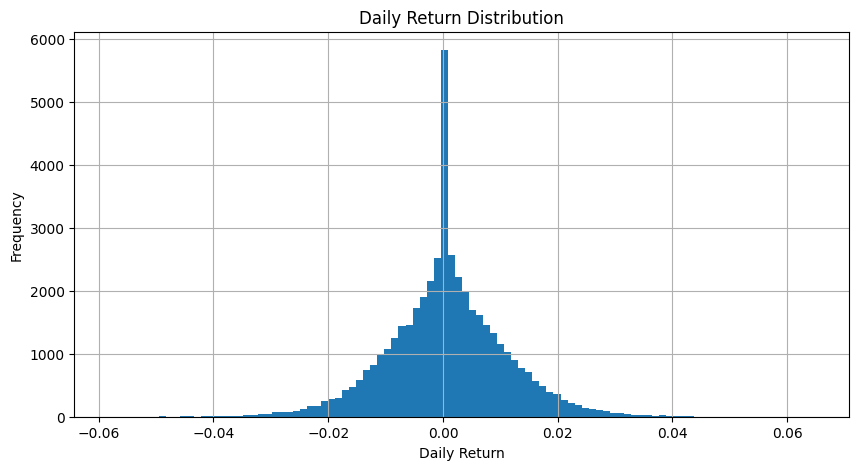

In [12]:
plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=100
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [13]:
daily_summary = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(
           mean_return="mean",
           std_return="std",
           min_return="min",
           max_return="max"
       )
       .reset_index()
)

daily_summary.head()

,amfi_code,mean_return,std_return,min_return,max_return
0,100016,0.000142,0.009164,-0.024744,0.032145
1,100025,0.000170,0.002460,-0.008188,0.008837
2,100033,0.001080,0.011929,-0.044238,0.041954
3,101206,0.000852,0.009177,-0.038121,0.033956
4,101207,0.000424,0.016251,-0.051847,0.054851


In [14]:
daily_summary = daily_summary.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

daily_summary.head()

,amfi_code,mean_return,std_return,min_return,max_return,scheme_name
0,100016,0.000142,0.009164,-0.024744,0.032145,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.000170,0.002460,-0.008188,0.008837,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.001080,0.011929,-0.044238,0.041954,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.000852,0.009177,-0.038121,0.033956,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.000424,0.016251,-0.051847,0.054851,ABSL Small Cap Fund - Regular - Growth


In [15]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_nav = nav[nav["amfi_code"] == fund].sort_values("date")

    latest_date = fund_nav["date"].max()

    latest_nav = fund_nav.iloc[-1]["nav"]

    # 1 Year CAGR
    start_1yr = latest_date - pd.DateOffset(years=1)

    nav_1yr = fund_nav[fund_nav["date"] >= start_1yr]

    if len(nav_1yr) > 0:
        cagr_1yr = (
            (latest_nav / nav_1yr.iloc[0]["nav"]) ** (1/1)
        ) - 1
    else:
        cagr_1yr = np.nan

    # 3 Year CAGR
    start_3yr = latest_date - pd.DateOffset(years=3)

    nav_3yr = fund_nav[fund_nav["date"] >= start_3yr]

    if len(nav_3yr) > 0:
        cagr_3yr = (
            (latest_nav / nav_3yr.iloc[0]["nav"]) ** (1/3)
        ) - 1
    else:
        cagr_3yr = np.nan

    cagr_results.append(
        [fund, cagr_1yr, cagr_3yr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr"
    ]
)

In [16]:
cagr_df = cagr_df.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,scheme_name
0,100016,-0.022243,0.012926,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,ABSL Small Cap Fund - Regular - Growth


In [17]:
cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

,amfi_code,cagr_1yr,cagr_3yr,scheme_name
16,119094,0.222611,0.351118,Axis Midcap Fund - Regular - Growth
34,148567,0.203607,0.340009,Mirae Asset Large Cap Fund - Regular - Growth
24,120504,0.130643,0.324874,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,0.532324,0.324425,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,0.296047,0.317775,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.604373,0.304565,SBI Bluechip Fund - Regular Plan - Growth
30,120843,0.266571,0.295828,Kotak Flexicap Fund - Regular - Growth
36,148569,0.397518,0.291789,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,0.479241,0.289677,ABSL Frontline Equity Fund - Regular - Growth
39,149324,0.651387,0.270004,DSP Small Cap Fund - Regular - Growth


In [22]:
cagr_df.to_csv(
    "../outputs/cagr_comparison.csv",
    index=False
)

print("CAGR table saved")

CAGR table saved


In [23]:
cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,scheme_name
0,100016,-0.022243,0.012926,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,ABSL Small Cap Fund - Regular - Growth


In [24]:
returns.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [25]:
returns[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio",
        "sortino_ratio",
        "max_drawdown_pct"
    ]
].head()

,scheme_name,return_1yr_pct,return_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,max_drawdown_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,0.87,0.89,0.88,1.29,-21.70
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,1.78,0.87,0.81,1.29,-24.43
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,1.23,0.89,0.94,1.35,-13.35
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,1.13,1.04,0.93,1.67,-24.78
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,1.60,0.22,1.52,2.11,-2.30


In [26]:
returns.isnull().sum()

amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

In [27]:
alpha_beta = returns[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [28]:
import os

os.makedirs("../outputs", exist_ok=True)

alpha_beta.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [29]:
fund_scorecard = returns[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "return_3yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio",
        "sortino_ratio",
        "max_drawdown_pct",
        "expense_ratio_pct",
        "morningstar_rating"
    ]
]

fund_scorecard.head()

,amfi_code,scheme_name,fund_house,category,return_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,max_drawdown_pct,expense_ratio_pct,morningstar_rating
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,12.36,0.87,0.89,0.88,1.29,-21.70,1.54,4
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,11.30,1.78,0.87,0.81,1.29,-24.43,0.66,3
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.39,1.23,0.89,0.94,1.35,-13.35,1.43,5
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,23.14,1.13,1.04,0.93,1.67,-24.78,0.72,4
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,6.07,1.60,0.22,1.52,2.11,-2.30,0.77,5


In [30]:
fund_scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [31]:
top_sharpe = returns.sort_values(
    "sharpe_ratio",
    ascending=False
)

top_sharpe[
    ["scheme_name", "sharpe_ratio"]
].head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [32]:
benchmark_compare = returns[
    [
        "scheme_name",
        "return_3yr_pct",
        "benchmark_3yr_pct"
    ]
].copy()

benchmark_compare["excess_return"] = (
    benchmark_compare["return_3yr_pct"]
    - benchmark_compare["benchmark_3yr_pct"]
)

benchmark_compare.head()

,scheme_name,return_3yr_pct,benchmark_3yr_pct,excess_return
0,SBI Bluechip Fund - Regular Plan - Growth,12.36,11.49,0.87
1,SBI Bluechip Fund - Direct Plan - Growth,11.30,9.52,1.78
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,22.16,1.23
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,22.01,1.13
4,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,4.47,1.60


In [33]:
benchmark_compare.sort_values(
    "excess_return",
    ascending=False
).head(10)

,scheme_name,return_3yr_pct,benchmark_3yr_pct,excess_return
9,HDFC Short Term Debt Fund - Regular - Growth,7.37,5.39,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,18.23,16.32,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,5.83,1.85
22,Kotak Flexicap Fund - Regular - Growth,15.65,13.80,1.85
29,ABSL Small Cap Fund - Regular - Growth,22.38,20.54,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,12.82,11.00,1.82
18,Nippon India ETF Nifty 50 BeES,11.77,9.97,1.80
33,UTI Flexi Cap Fund - Regular - Growth,15.34,13.55,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,11.30,9.52,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,14.56,12.86,1.70
